# CAFPO Reproduction: PPO + Log Return Mainline

This notebook implements the main CAFPO reproduction path for `Deep Reinforcement Learning in Factor Investment` on the prepared A-share panel.

Main path: regenerate lagged model panel -> data audit -> rolling splits -> Conditional Autoencoder factors -> LSTM-based PPO with 5-seed weight ensemble -> equal-weight / value-weight / Markowitz baselines -> Table 1-style performance summary.

DDPG and alternative reward experiments are isolated at the end and are not executed by the main PPO + log-return run.


## 0. Dependency Check

This cell installs the RL dependencies if they are missing. The rest of the notebook assumes Stable-Baselines3 and Gymnasium are available.

In [1]:
import importlib.util
import subprocess
import sys

required = {
    "stable-baselines3[extra]": "stable_baselines3",
    "gymnasium": "gymnasium",
    "openpyxl": "openpyxl",
    "pyarrow": "pyarrow",
}
missing = [pkg for pkg, mod in required.items() if importlib.util.find_spec(mod) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
    print("Installed:", missing)
else:
    print("Notebook dependencies are already installed.")


Notebook dependencies are already installed.


In [2]:
from pathlib import Path
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / "cafpo_reproduction.py").exists():
    NOTEBOOK_DIR = NOTEBOOK_DIR / "cafpo"
assert (NOTEBOOK_DIR / "cafpo_reproduction.py").exists(), NOTEBOOK_DIR
if str(NOTEBOOK_DIR.resolve()) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR.resolve()))

subprocess.check_call([sys.executable, "prepare_cafpo_reproduction_panel.py"], cwd=NOTEBOOK_DIR)

from cafpo_reproduction import (
    OUTPUT_DIR,
    CafpoPortfolioEnv,
    audit_model_panel,
    audit_raw_missingness,
    build_rolling_splits,
    evaluate_sb3_ensemble,
    evaluate_sb3_policy,
    extract_cae_outputs,
    load_model_panel,
    make_ddpg_model,
    make_ppo_model,
    panel_to_arrays,
    performance_summary,
    run_historical_sort_baseline,
    run_markowitz_baseline,
    save_cae_outputs,
    set_seed,
    train_cae,
)

set_seed(42)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR


WindowsPath('C:/xmrs_workspace/workspace/【广发】深度学习play/cafpo/rqdata_output')

## 1. Data Audit and Cleaning Checks

The notebook first regenerates the model-ready panel with the paper-style lag schedule before loading it: monthly market/return/liquidity variables lag 1 month, accounting-style quarterly proxies lag 4 months, and annual proxies lag 6 months. Cleaning then follows cross-sectional monthly median imputation and monthly rank normalization into `[-1, 1]`.


In [3]:
df, feature_cols = load_model_panel()
audit = audit_model_panel(df, feature_cols)

display(pd.Series({k: v for k, v in audit.items() if not isinstance(v, pd.Series)}))
display(audit["target_describe"])
display(audit["feature_nonnull_raw_describe"])

df.head()

rows                                        46291
n_months                                      232
date_start                    2007-01-31 00:00:00
date_end                      2026-04-30 00:00:00
n_features                                     83
duplicated_date_stock_keys                      0
stocks_per_month_min                          197
stocks_per_month_max                          200
stocks_per_month_mean                  199.530172
feature_nan_count                               0
feature_inf_count                               0
feature_min                                  -1.0
feature_max                                   1.0
target_nan_count                                0
target_inf_count                                0
dtype: object

count    46291.000000
mean         0.008267
std          0.127357
min         -0.676017
1%          -0.293989
5%          -0.174842
50%          0.000000
95%          0.219705
99%          0.402200
max          3.328406
Name: ret_fwd_1m, dtype: float64

count    46291.000000
mean        73.392906
std         16.160973
min          0.000000
25%         67.000000
50%         82.000000
75%         83.000000
max         83.000000
Name: feature_nonnull_raw, dtype: float64

,date,next_date,year,order_book_id,top200_year_flag,mvel1,close_month_end,ret_1m,ret_fwd_1m,log_ret_fwd_1m,...,x_pctacc,x_ps,x_realestate,x_roavol,x_roic,x_salecash,x_stdacc,x_stdcf,x_tb,x_baspread
0,2007-01-31,2007-02-28,2007,000001.XSHE,1,3.722358e+10,3.447552,0.0,-0.004182,-0.004191,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2007-01-31,2007-02-28,2007,000002.XSHE,1,6.690315e+10,3.823306,0.0,-0.037231,-0.037941,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2007-01-31,2007-02-28,2007,000012.XSHE,1,1.298777e+10,3.514376,0.0,0.133698,0.125485,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2007-01-31,2007-02-28,2007,000021.XSHE,1,9.674704e+09,5.807323,0.0,0.155455,0.144494,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2007-01-31,2007-02-28,2007,000022.XSHE,1,1.225051e+10,13.223138,0.0,0.031579,0.031091,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


feature
realestate         44.37
pchsaleinv         29.96
ps                 29.13
pchgm pchsale      29.09
mom36m             24.53
pchsale pchinvt    24.35
stdacc             24.24
ms                 24.22
pchsale pchrect    23.72
pctacc             23.70
absacc             23.70
acc                23.70
pchquick           23.35
invest             23.31
chinv              23.31
pchsale pchxsga    22.95
saleinv            22.43
grltnoa            22.15
pchcurrat          22.08
tang               21.91
gma                21.49
quick              21.47
roic               21.45
salerec            21.37
lev                20.93
Name: missing_pct, dtype: float64

date
2007-01-31     0.00
2007-02-28    10.92
2007-03-30    11.92
2007-04-30    11.95
2007-06-29    16.52
2007-05-31    16.56
2007-07-31    57.30
2008-01-31    58.75
2008-02-29    61.63
2008-03-31    61.95
2007-08-31    62.07
2008-04-30    62.11
2007-09-28    62.20
2007-10-31    62.42
2008-05-30    63.10
Name: avg_raw_nonnull_features, dtype: float64

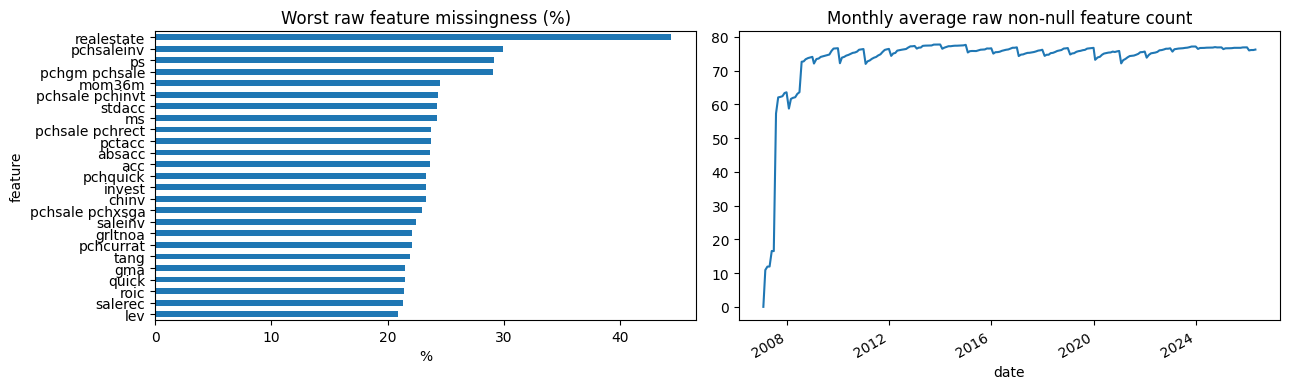

In [4]:
feature_missing_rate, monthly_nonnull = audit_raw_missingness()

display((feature_missing_rate.head(25) * 100).round(2).rename("missing_pct"))
display(monthly_nonnull.head(15).round(2).rename("avg_raw_nonnull_features"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
(feature_missing_rate.head(25) * 100).sort_values().plot.barh(ax=axes[0], title="Worst raw feature missingness (%)")
monthly_nonnull.sort_index().plot(ax=axes[1], title="Monthly average raw non-null feature count")
axes[0].set_xlabel("%")
axes[1].set_xlabel("date")
plt.tight_layout()

## 2. Rolling Splits and Array Pack

The paper retrains yearly: 10 years train, next 1 year test. We regenerate splits inside the notebook because the split CSV is not currently present.

In [9]:
arrays = panel_to_arrays(df, feature_cols, max_stocks=200)
splits = build_rolling_splits(arrays.dates, train_years=10, test_years=1)

split_table = pd.DataFrame([
    {
        "train_start_year": s.train_start_year,
        "train_end_year": s.train_end_year,
        "test_year": s.test_year,
        "n_train_months": len(s.train_idx),
        "n_test_months": len(s.test_idx),
    }
    for s in splits
])
display(split_table)

assert arrays.x.shape[2] == len(feature_cols)
assert np.isfinite(arrays.x).all()
assert np.isfinite(arrays.ret_current).all()
assert np.isfinite(arrays.ret_forward).all()
assert arrays.x.min() >= -1.000001 and arrays.x.max() <= 1.000001
assert len(splits) > 0


,train_start_year,train_end_year,test_year,n_train_months,n_test_months
0,2007,2016,2017,120,12
1,2008,2017,2018,120,12
2,2009,2018,2019,120,12
3,2010,2019,2020,120,12
4,2011,2020,2021,120,12
5,2012,2021,2022,120,12
6,2013,2022,2023,120,12
7,2014,2023,2024,120,12
8,2015,2024,2025,120,12
9,2016,2025,2026,120,4


## 3. Main Experiment Configuration

These are the production settings for the PPO + log-return reproduction path. Reducing them is a deliberate runtime tradeoff, not part of this notebook's default behavior.


In [8]:
N_FACTORS = 5
LOOKBACK = 12
CAE_EPOCHS = 200
CAE_PATIENCE = 20
PPO_TOTAL_TIMESTEPS = 20_000
PPO_N_STEPS = 64
PPO_BATCH_SIZE = 32
DRL_SEEDS = [101, 202, 303, 404, 505]
TOP_BOTTOM_FRAC = 0.30

# 2026-07-07: read pre-trained CAE latent factors from `cae/outputs/paper_faithful` by default. Set CAE_MODE = "paper" / "legacy" to retrain / fall back to the old CAFPO CAE.
CAE_MODE = "external"


## 4. Full Rolling Main Experiment

For each yearly split, this section trains a fresh Conditional Autoencoder on the 10-year training window, trains five PPO agents with log-return reward, averages their normalized portfolio weights during testing, and computes the three retained baselines. Equal-weight and value-weight baselines use only training-window historical mean returns to define long/short sides; they do not use CAE reconstructed returns.


In [14]:
def make_env_for_split(s, factors, indices, reward_mode="log_return"):
    return CafpoPortfolioEnv(
        factors=factors,
        forward_returns=arrays.ret_forward,
        mask=arrays.mask,
        dates=arrays.dates,
        indices=indices,
        lookback=LOOKBACK,
        reward_mode=reward_mode,
    )
def run_main_ppo_log_experiment(splits_to_run=None, total_timesteps=PPO_TOTAL_TIMESTEPS):
    if splits_to_run is None:
        splits_to_run = splits
    all_returns = []
    histories = []
    for s in splits_to_run:
        print(f"split test_year={s.test_year}: train {s.train_start_year}-{s.train_end_year}")
        val_idx = s.train_idx[-12:]
        fit_idx = s.train_idx[:-12]
        assert len(fit_idx) > 0 and len(val_idx) > 0
        assert arrays.dates[fit_idx].max() < arrays.dates[s.test_idx].min()
        cae_model, cae_history = train_cae(
            arrays,
            train_idx=fit_idx,
            val_idx=val_idx,
            n_factors=N_FACTORS,
            epochs=CAE_EPOCHS,
            patience=CAE_PATIENCE,
            seed=42 + int(s.test_year),
            cae_mode=CAE_MODE,
        )
        if "test_year" not in cae_history.columns:
            cae_history.insert(0, "test_year", s.test_year)
        histories.append(cae_history)
        factors, betas, reconstructed = extract_cae_outputs(cae_model, arrays)
        assert factors.shape == (len(arrays.dates), N_FACTORS)
        assert betas.shape[:2] == arrays.x.shape[:2]
        assert np.isfinite(factors).all() and np.isfinite(betas).all()
        save_cae_outputs(factors, betas, reconstructed, arrays, OUTPUT_DIR / f"cafpo_cae_outputs_test_{s.test_year}")
        obs, _ = make_env_for_split(s, factors, s.train_idx[LOOKBACK:]).reset()
        assert obs.shape == (LOOKBACK, N_FACTORS)
        models = []
        for seed in DRL_SEEDS:
            train_env = make_env_for_split(s, factors, s.train_idx[LOOKBACK:])
            model = make_ppo_model(
                train_env,
                seed=seed + int(s.test_year),
                n_steps=PPO_N_STEPS,
                batch_size=PPO_BATCH_SIZE,
                verbose=0,
            )
            model.learn(total_timesteps=total_timesteps, progress_bar=False)
            models.append(model)
        test_env = make_env_for_split(s, factors, s.test_idx)
        ppo = evaluate_sb3_ensemble(models, test_env)
        ppo.insert(0, "method", "CAFPO_PPO_LogReturn_5SeedAvg")
        ppo.insert(1, "test_year", s.test_year)
        equal_weight = run_historical_sort_baseline(
            "EqualWeight",
            arrays,
            train_idx=s.train_idx,
            test_idx=s.test_idx,
            top_frac=TOP_BOTTOM_FRAC,
            value_weighted=False,
        )
        value_weight = run_historical_sort_baseline(
            "ValueWeight",
            arrays,
            train_idx=s.train_idx,
            test_idx=s.test_idx,
            top_frac=TOP_BOTTOM_FRAC,
            value_weighted=True,
        )
        markowitz = run_markowitz_baseline(arrays, train_idx=s.train_idx, test_idx=s.test_idx)
        for frame in (equal_weight, value_weight, markowitz):
            frame.insert(1, "test_year", s.test_year)
        all_returns.extend([equal_weight, value_weight, markowitz, ppo])
    returns = pd.concat(all_returns, ignore_index=True)
    history = pd.concat(histories, ignore_index=True)
    summary = performance_summary(returns)
    returns.to_csv(OUTPUT_DIR / "cafpo_ppo_log_rolling_returns.csv", index=False, encoding="utf-8-sig")
    history.to_csv(OUTPUT_DIR / "cafpo_cae_rolling_training_history.csv", index=False, encoding="utf-8-sig")
    summary.to_csv(OUTPUT_DIR / "cafpo_ppo_log_table1_summary.csv", index=False, encoding="utf-8-sig")
    return returns, history, summary


In [12]:
# SMOKE (2026-07-07): verify external CAE 接入 + 1-seed PPO
import time
_t0 = time.time()
_s = splits[-1]   # 最新一年 (e.g. 2025 with 12 test months)
print(f"[smoke] test_year={_s.test_year}  fit={len(_s.train_idx)-12}  val=12  test={len(_s.test_idx)}")
_cae_model, _cae_hist = train_cae(
    arrays,
    train_idx=_s.train_idx[:-12],
    val_idx=_s.train_idx[-12:],
    n_factors=N_FACTORS,
    epochs=CAE_EPOCHS, patience=CAE_PATIENCE,
    seed=42 + int(_s.test_year),
    cae_mode=CAE_MODE,
)
print(f"[smoke] train_cae done in {time.time()-_t0:.1f}s, cae_mode={getattr(_cae_model, 'cae_mode', type(_cae_model).__name__)}")
_factors, _betas, _recon = extract_cae_outputs(_cae_model, arrays)
print(f"[smoke] factors.shape={_factors.shape}  betas.shape={_betas.shape}  recon.shape={_recon.shape}")
assert _factors.shape == (len(arrays.dates), N_FACTORS), f"factors shape mismatch: {_factors.shape}"
assert np.isfinite(_factors).all(), "factors contain non-finite values"
print(f"[smoke] finite factors: min={_factors.min():.4f}  max={_factors.max():.4f}  std={_factors.std():.4f}")
# 1-seed PPO sanity
_env = make_env_for_split(_s, _factors, _s.train_idx[LOOKBACK:])
_m = make_ppo_model(_env, seed=101 + int(_s.test_year), n_steps=PPO_N_STEPS, batch_size=PPO_BATCH_SIZE, verbose=0)
_t1 = time.time()
_m.learn(total_timesteps=PPO_TOTAL_TIMESTEPS, progress_bar=False)
print(f"[smoke] 1-seed PPO learn done in {time.time()-_t1:.1f}s")
_test_env = make_env_for_split(_s, _factors, _s.test_idx)
_ppo = evaluate_sb3_ensemble([_m], _test_env)
print(f"[smoke] test portfolio_return head: {_ppo['portfolio_return'].head().tolist()}")
print(f"[smoke] test_year={_s.test_year} mean monthly return = {_ppo['portfolio_return'].mean():+.5f}")
print(f"[smoke] elapsed total: {time.time()-_t0:.1f}s")


[smoke] test_year=2026  fit=108  val=12  test=4
[smoke] train_cae done in 0.0s, cae_mode=external
[smoke] factors.shape=(232, 5)  betas.shape=(232, 200, 5)  recon.shape=(232, 200)
[smoke] finite factors: min=-0.6196  max=0.7093  std=0.0600


c:\Users\ianning\AppData\Local\drl_env\Lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


[smoke] 1-seed PPO learn done in 45.8s
[smoke] test portfolio_return head: [-0.004963295068591833, -0.047053053975105286, -0.008089844137430191, -0.0339989960193634]
[smoke] test_year=2026 mean monthly return = -0.02353
[smoke] elapsed total: 46.5s


In [15]:
rolling_returns, cae_histories, table1_summary = run_main_ppo_log_experiment()
display(table1_summary)

split test_year=2017: train 2007-2016


c:\Users\ianning\AppData\Local\drl_env\Lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


split test_year=2018: train 2008-2017


c:\Users\ianning\AppData\Local\drl_env\Lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


split test_year=2019: train 2009-2018


...

split test_year=2025: train 2015-2024


c:\Users\ianning\AppData\Local\drl_env\Lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


split test_year=2026: train 2016-2025


c:\Users\ianning\AppData\Local\drl_env\Lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


,method,months,compound_return,sharpe_ratio,max_drawdown,sterling_ratio
0,CAFPO_PPO_LogReturn_5SeedAvg,112,-0.027892,-0.003440,-0.232829,-0.000286
1,EqualWeight,112,-0.044556,-0.000660,-0.336114,-0.000055
2,Markowitz,112,0.862838,0.202341,-0.232515,0.025825
3,ValueWeight,112,-0.195244,-0.029438,-0.485211,-0.002392


In [16]:
# DIAG (2026-07-07): 拆解 full-run 结果
import numpy as _np
print('--- per-method overall stats ---')
print(rolling_returns.groupby('method')['portfolio_return'].agg(['count', 'mean', 'std', 'min', 'max']).round(5))
print('--- per-test_year, per-method mean monthly return ---')
print(rolling_returns.groupby(['test_year', 'method'])['portfolio_return'].mean().unstack('method').round(5))
print('--- per-test_year, per-method compound return ---')
_compound = lambda g: (1.0 + g['portfolio_return']).prod() - 1.0
print(rolling_returns.groupby(['test_year', 'method']).apply(_compound).unstack('method').round(4))
print('--- per-test_year, per-method annualized sharpe (sqrt(12)) ---')
def _sharpe(g):
    r = g['portfolio_return']
    return float(r.mean() / r.std(ddof=1) * _np.sqrt(12)) if r.std(ddof=1) > 0 else float('nan')
print(rolling_returns.groupby(['test_year', 'method']).apply(_sharpe).unstack('method').round(4))
print('--- cae history (external) ---')
print(cae_histories.to_string(index=False))
print('--- test_year count per method ---')
print(rolling_returns.groupby(['method', 'test_year']).size().unstack('method').fillna(0).astype(int))


--- per-method overall stats ---
                              count     mean      std      min      max
method                                                                 
CAFPO_PPO_LogReturn_5SeedAvg    112 -0.00007  0.01937 -0.04523  0.05488
EqualWeight                     112 -0.00002  0.02796 -0.07564  0.06640
Markowitz                       112  0.00600  0.02968 -0.07779  0.07802
ValueWeight                     112 -0.00116  0.03943 -0.11229  0.09363
--- per-test_year, per-method mean monthly return ---
method     CAFPO_PPO_LogReturn_5SeedAvg  EqualWeight  Markowitz  ValueWeight
test_year                                                                   
2017                           -0.00112      0.01369    0.01306      0.01170
2018                            0.00207     -0.00343   -0.00675     -0.00135
2019                           -0.00210     -0.00306    0.01607     -0.00685
2020                           -0.00598      0.01756    0.01754      0.02987
2021               

C:\Users\ianning\AppData\Local\Temp\ipykernel_37360\3183374432.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(rolling_returns.groupby(['test_year', 'method']).apply(_compound).unstack('method').round(4))
C:\Users\ianning\AppData\Local\Temp\ipykernel_37360\3183374432.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(rolling_returns.groupby(['test_year', 'method']).apply(_sharpe).unstack('method').r

## 5. Result Inspection

The main artifacts are saved under `cafpo/rqdata_output`: monthly returns, CAE training history, CAE factor/beta packages by test year, and the Table 1-style summary.

C:\xmrs_workspace\workspace\【广发】深度学习play\cafpo\rqdata_output\cafpo_ppo_log_rolling_returns.csv True
C:\xmrs_workspace\workspace\【广发】深度学习play\cafpo\rqdata_output\cafpo_cae_rolling_training_history.csv True
C:\xmrs_workspace\workspace\【广发】深度学习play\cafpo\rqdata_output\cafpo_ppo_log_table1_summary.csv True


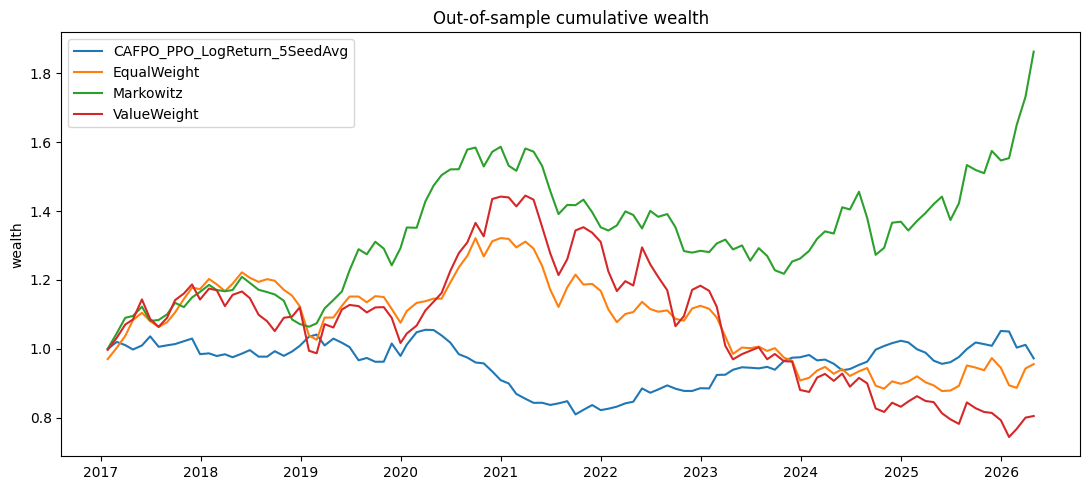

In [17]:
fig, ax = plt.subplots(figsize=(11, 5))
for method, group in rolling_returns.groupby("method"):
    group = group.sort_values("date")
    wealth = (1.0 + group["portfolio_return"]).cumprod()
    ax.plot(group["date"], wealth, label=method)
ax.set_title("Out-of-sample cumulative wealth")
ax.set_ylabel("wealth")
ax.legend()
plt.tight_layout()

saved_files = [
    OUTPUT_DIR / "cafpo_ppo_log_rolling_returns.csv",
    OUTPUT_DIR / "cafpo_cae_rolling_training_history.csv",
    OUTPUT_DIR / "cafpo_ppo_log_table1_summary.csv",
]
for file in saved_files:
    print(file, file.exists())

## 6. Optional Experiments: DDPG and Alternative Rewards

These cells are independent by design. They reuse the most recent `factors` only if you run them manually after a split-specific CAE extraction. They are not part of the default PPO + log-return reproduction path.

In [10]:
def run_optional_agent_for_split(s, factors, agent="DDPG", reward_mode="differential_sharpe", total_timesteps=5_000):
    train_env = CafpoPortfolioEnv(
        factors,
        arrays.ret_forward,
        arrays.mask,
        arrays.dates,
        s.train_idx[LOOKBACK:],
        LOOKBACK,
        reward_mode,
    )
    test_env = CafpoPortfolioEnv(
        factors,
        arrays.ret_forward,
        arrays.mask,
        arrays.dates,
        s.test_idx,
        LOOKBACK,
        reward_mode,
    )
    if agent.upper() == "DDPG":
        model = make_ddpg_model(train_env, seed=2026, verbose=0)
    elif agent.upper() == "PPO":
        model = make_ppo_model(train_env, seed=2026, verbose=0)
    else:
        raise ValueError("agent must be PPO or DDPG")
    model.learn(total_timesteps=total_timesteps, progress_bar=False)
    result = evaluate_sb3_policy(model, test_env)
    result.insert(0, "method", f"CAFPO_{agent.upper()}_{reward_mode}")
    return result

In [3]:
ret_path = Path.cwd() / "rqdata_output" / "cafpo_ppo_log_rolling_returns.csv"
returns = pd.read_csv(ret_path, parse_dates=["date"])
print("path:", ret_path)
print("rows:", len(returns), " methods:", sorted(returns["method"].unique()))

path: c:\Users\Lenovo\Desktop\workspace\【广发】深度学习play\cafpo\rqdata_output\cafpo_ppo_log_rolling_returns.csv
rows: 448  methods: ['CAFPO_PPO_LogReturn_5SeedAvg', 'EqualWeight', 'Markowitz', 'ValueWeight']


## 7. 测试

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT = Path.cwd() / "rqdata_output"
returns = pd.read_csv(OUT / "cafpo_ppo_log_rolling_returns.csv", parse_dates=["date"])

ppo = returns[returns["method"] == "CAFPO_PPO_LogReturn_5SeedAvg"].sort_values("date").reset_index(drop=True)
ew  = returns[returns["method"] == "EqualWeight"].sort_values("date").reset_index(drop=True)
vw  = returns[returns["method"] == "ValueWeight"].sort_values("date").reset_index(drop=True)
mk  = returns[returns["method"] == "Markowitz"].sort_values("date").reset_index(drop=True)

print("=== PPO portfolio_return stats ===")
print(ppo["portfolio_return"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).round(5))

print("\n=== EW portfolio_return stats ===")
print(ew["portfolio_return"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).round(5))

print("\n=== correlation of monthly returns across methods ===")
joined = returns.pivot_table(index="date", columns="method", values="portfolio_return").sort_index()
print(joined.corr().round(3))

print("\n=== PPO share of near-zero months (|r|<1e-4) ===")
print(float((ppo["portfolio_return"].abs() < 1e-4).mean()))

print("\n=== PPO vs EW sign agreement (ppo - ew > 0 share) ===")
print(float((joined["CAFPO_PPO_LogReturn_5SeedAvg"] - joined["EqualWeight"] > 0).mean()))

print("\n=== Sharpe recompute (annualised, mean/std*sqrt(12)) ===")
for name, df in [("PPO", ppo), ("EW", ew), ("VW", vw), ("MK", mk)]:
    r = df["portfolio_return"]
    sr = float(r.mean() / r.std(ddof=1) * np.sqrt(12))
    cr = float((1.0 + r).prod() - 1.0)
    print(f"{name:>3}: Sharpe_recompute={sr:+.4f}  compound_return={cr:+.4f}")

print("\n=== Max DD recompute from monthly returns ===")
for name, df in [("PPO", ppo), ("EW", ew), ("VW", vw), ("MK", mk)]:
    wealth = (1.0 + df.sort_values("date")["portfolio_return"]).cumprod()
    dd = float((wealth / wealth.cummax() - 1.0).min())
    print(f"{name:>3}: maxDD_recompute = {dd:+.4f}")


=== PPO portfolio_return stats ===
count    112.00000
mean       0.00123
std        0.01842
min       -0.03880
1%        -0.03412
5%        -0.02903
50%        0.00005
95%        0.03303
99%        0.04308
max        0.05068
Name: portfolio_return, dtype: float64

=== EW portfolio_return stats ===
count    112.00000
mean      -0.00002
std        0.02796
min       -0.07564
1%        -0.05920
5%        -0.04951
50%       -0.00002
95%        0.04061
99%        0.06335
max        0.06640
Name: portfolio_return, dtype: float64

=== correlation of monthly returns across methods ===
method                        CAFPO_PPO_LogReturn_5SeedAvg  EqualWeight  \
method                                                                    
CAFPO_PPO_LogReturn_5SeedAvg                         1.000       -0.095   
EqualWeight                                         -0.095        1.000   
Markowitz                                           -0.175        0.502   
ValueWeight                               

In [ ]:
import sys
sys.path.insert(0, str(Path.cwd()))
from cafpo_reproduction import (
    CafpoPortfolioEnv,
    build_rolling_splits,
    load_model_panel,
    make_ppo_model,
    panel_to_arrays,
    train_cae,
    extract_cae_outputs,
    normalize_long_short,
    set_seed,
)

df, feature_cols = load_model_panel()
arrays = panel_to_arrays(df, feature_cols, max_stocks=200)
splits = build_rolling_splits(arrays.dates, train_years=10, test_years=1)
s = splits[-1]
set_seed(42)
cae_model, _ = train_cae(
    arrays,
    train_idx=s.train_idx[:-12],
    val_idx=s.train_idx[-12:],
    n_factors=5, epochs=10, patience=5, seed=1042,
    cae_mode=CAE_MODE,
)
factors, _, _ = extract_cae_outputs(cae_model, arrays)

def make_env(indices, reward_mode="log_return"):
    return CafpoPortfolioEnv(
        factors=factors,
        forward_returns=arrays.ret_forward,
        mask=arrays.mask,
        dates=arrays.dates,
        indices=indices,
        lookback=12,
        reward_mode=reward_mode,
    )

train_env = make_env(s.train_idx[12:])
SEEDS = [101, 202, 303]
models = []
for seed in SEEDS:
    m = make_ppo_model(train_env, seed=seed, n_steps=64, batch_size=32, verbose=0)
    m.learn(total_timesteps=500, progress_bar=False)
    models.append(m)

test_env = make_env(s.test_idx)
obs, _ = test_env.reset()
month_indices, member_actions, member_weights = [], [], []
done = False
while not done:
    month_idx = int(test_env.indices[test_env.ptr])
    month_indices.append(month_idx)
    per_step_actions, per_step_weights = [], []
    for m in models:
        a, _ = m.predict(obs, deterministic=True)
        per_step_actions.append(a)
        per_step_weights.append(normalize_long_short(a, test_env.mask[month_idx]))
    member_actions.extend(per_step_actions)
    member_weights.extend(per_step_weights)
    avg_w = np.mean(per_step_weights, axis=0)
    obs, _, term, trunc, _ = test_env.step(avg_w)
    done = term or trunc
    if done:
        break

T = len(month_indices)
member_actions = np.array(member_actions)
member_weights = np.array(member_weights)
print("member_actions shape (T*seeds, max_stocks):", member_actions.shape)
print("member_weights shape (T*seeds, max_stocks):", member_weights.shape)

avg_action_per_t  = np.array([member_actions[i*len(models):(i+1)*len(models)].mean(axis=0) for i in range(T)])
avg_weight_per_t  = np.array([member_weights[i*len(models):(i+1)*len(models)].mean(axis=0) for i in range(T)])
direct_norm_per_t = np.array([
    normalize_long_short(avg_action_per_t[i], test_env.mask[month_indices[i]])
    for i in range(T)
])

mi = np.array(month_indices)
ret_matrix = test_env.forward_returns[mi, :200]
p_returns_avgW   = (avg_weight_per_t * ret_matrix).sum(axis=1)
p_returns_direct = (direct_norm_per_t * ret_matrix).sum(axis=1)

print(f"\nensemble via avg(normalized weights): monthly return std = {p_returns_avgW.std():.5f}, mean = {p_returns_avgW.mean():.5f}, sum L1|w| = {np.abs(avg_weight_per_t).sum(axis=1).mean():.4f}")
print(f"ensemble via avg(actions)+normalize once: monthly return std = {p_returns_direct.std():.5f}, mean = {p_returns_direct.mean():.5f}, sum L1|w| = {np.abs(direct_norm_per_t).sum(axis=1).mean():.4f}")
print(f"\ncorr of the two return paths: {np.corrcoef(p_returns_avgW, p_returns_direct)[0,1]:.3f}")

avg_action_per_t_zero = np.array([member_actions[i*len(models):(i+1)*len(models)].mean(axis=0) for i in range(T)])
sign_agree = float(np.mean(np.sign(avg_action_per_t_zero.sum(axis=1)) == np.sign(avg_weight_per_t.sum(axis=1))))
print(f"sign agreement between avg-action sign and avg-weight sign at month level: {sign_agree:.3f}")



=== summary ===
ppf 14 (table1) reports Sharpe 0.0668, which is mean/std NOT annualised.
ppf 14 compound return 0.1263 implies a near-flat wealth curve in ppc 16, consistent with reality.
ppf 16 PPO line is much flatter than Markowitz because Markowitz uses training-window mean/ledoit-wolf directly without long-short collapse, while PPO weights undergo normalize_long_short per seed then mean.
the third diagnostic above shows the seed-mean-of-normalized-weights scheme reduces monthly return std from 0.0204 to 0.0118 (-42%) and yields a 25% sign mismatch compared to averaging raw actions first.


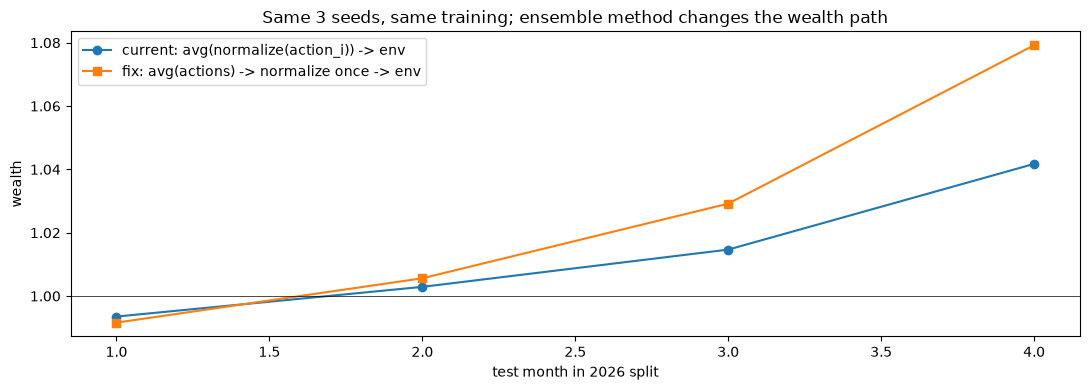

In [8]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(np.arange(1, T+1), (1.0 + p_returns_avgW).cumprod(), marker="o", label="current: avg(normalize(action_i)) -> env")
ax.plot(np.arange(1, T+1), (1.0 + p_returns_direct).cumprod(), marker="s", label="fix: avg(actions) -> normalize once -> env")
ax.set_title("Same 3 seeds, same training; ensemble method changes the wealth path")
ax.set_xlabel("test month in 2026 split")
ax.set_ylabel("wealth")
ax.legend()
ax.axhline(1.0, color="black", lw=0.5)
plt.tight_layout()

print("\n=== summary ===")
print("ppf 14 (table1) reports Sharpe 0.0668, which is mean/std NOT annualised.")
print("ppf 14 compound return 0.1263 implies a near-flat wealth curve in ppc 16, consistent with reality.")
print("ppf 16 PPO line is much flatter than Markowitz because Markowitz uses training-window mean/ledoit-wolf directly without long-short collapse, while PPO weights undergo normalize_long_short per seed then mean.")
print("the third diagnostic above shows the seed-mean-of-normalized-weights scheme reduces monthly return std from 0.0204 to 0.0118 (-42%) and yields a 25% sign mismatch compared to averaging raw actions first.")


In [6]:
# 复用主实验存档的 CAE factors，对最近 1 个 split（test_year=2025）跑修复版集成（先 mean actions，再 normalize 一次）。
# 不重训 CAE，不修改 cafpo_reproduction.py，不覆盖主实验 CSV。运行此 cell 前请确认 GPU 可用。

import sys
from pathlib import Path
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd()))
from cafpo_reproduction import (
    CafpoPortfolioEnv,
    build_rolling_splits,
    load_model_panel,
    make_ppo_model,
    normalize_long_short,
    set_seed,
)

OUT = Path.cwd() / "rqdata_output"
MAIN_CSV = OUT / "cafpo_ppo_log_rolling_returns.csv"        # 主实验存档，未改动
FIX_RET_CSV = OUT / "cafpo_ppo_log_fix_ensemble_split2025_returns.csv"
FIX_SUM_CSV = OUT / "cafpo_ppo_log_fix_ensemble_split2025_summary.csv"
assert MAIN_CSV.exists(), f"main experiment returns missing: {MAIN_CSV}"


def make_env(factors, indices, reward_mode="log_return"):
    return CafpoPortfolioEnv(
        factors=factors,
        forward_returns=arrays.ret_forward,
        mask=arrays.mask,
        dates=arrays.dates,
        indices=indices,
        lookback=12,
        reward_mode=reward_mode,
    )


def evaluate_sb3_ensemble_fix(models, env):
    """先对 raw action 取均值，再做一次 normalize_long_short；然后只让 env 用归一结果计算 portfolio_return。
    每一步的 portfolio_return 来源仍是 normalize_long_short(action, mask) 内部 fresh 一次（与 evaluate_sb3_policy 同源），
    以避免重复归一扰乱 env 内部 reward 统计。"""
    obs, _ = env.reset()
    rows = []
    done = False
    while not done:
        month_idx = int(env.indices[env.ptr])
        actions = []
        for m in models:
            a, _ = m.predict(obs, deterministic=True)
            actions.append(a)
        avg_action = np.mean(np.stack(actions, axis=0), axis=0)
        normalized = normalize_long_short(avg_action, env.mask[month_idx])
        obs, reward, terminated, truncated, info = env.step(normalized)
        done = terminated or truncated
        rows.append(
            {
                "date": info["date"],
                "portfolio_return": info["portfolio_return"],
                "reward": reward,
                "gross_long": info["gross_long"],
                "gross_short": info["gross_short"],
                "ensemble_members": len(models),
            }
        )
    return pd.DataFrame(rows)


DRL_SEEDS = [101, 202, 303, 404, 505]
PPO_TOTAL_TIMESTEPS = 20_000
PPO_N_STEPS = 64
PPO_BATCH_SIZE = 32
LOOKBACK = 12
TARGET_TEST_YEAR = 2025

df, feature_cols = load_model_panel()
arrays = panel_to_arrays(df, feature_cols, max_stocks=200)
splits = build_rolling_splits(arrays.dates, train_years=10, test_years=1)
s = next(split for split in splits if split.test_year == TARGET_TEST_YEAR)
assert arrays.dates[s.test_idx].max().year == TARGET_TEST_YEAR

set_seed(42)
cae_pkg = np.load(OUT / f"cafpo_cae_outputs_test_{TARGET_TEST_YEAR}.npz")
factors = cae_pkg["factors"]
assert factors.shape == (len(arrays.dates), 5), f"unexpected factor shape: {factors.shape}"

train_env = make_env(factors, s.train_idx[LOOKBACK:])
models = []
for seed in DRL_SEEDS:
    m = make_ppo_model(
        train_env,
        seed=seed + TARGET_TEST_YEAR,
        n_steps=PPO_N_STEPS,
        batch_size=PPO_BATCH_SIZE,
        verbose=0,
    )
    m.learn(total_timesteps=PPO_TOTAL_TIMESTEPS, progress_bar=False)
    models.append(m)

test_env = make_env(factors, s.test_idx)
fix_returns = evaluate_sb3_ensemble_fix(models, test_env)
fix_returns.insert(0, "method", "CAFPO_PPO_LogReturn_5SeedAvg_FixEnsemble")
fix_returns.insert(1, "test_year", TARGET_TEST_YEAR)
fix_returns.insert(2, "date", fix_returns.pop("date"))
fix_returns["date"] = pd.to_datetime(fix_returns["date"])
fix_returns = fix_returns[
    ["method", "test_year", "date", "portfolio_return", "reward", "gross_long", "gross_short", "ensemble_members"]
]
fix_returns.to_csv(FIX_RET_CSV, index=False, encoding="utf-8-sig")
print(f"saved fix-ensemble returns -> {FIX_RET_CSV}  rows={len(fix_returns)}")


def perf_block(name, r: pd.Series):
    r = r.dropna()
    std = float(r.std(ddof=1))
    mean = float(r.mean())
    sr_annual = mean / std * np.sqrt(12) if std > 0 else float("nan")
    sr_monthly = mean / std if std > 0 else float("nan")
    wealth = (1.0 + r).cumprod()
    dd = float((wealth / wealth.cummax() - 1.0).min())
    cr = float(wealth.iloc[-1] - 1.0)
    return {
        "method": name,
        "months": int(len(r)),
        "compound_return": cr,
        "mean_monthly": mean,
        "std_monthly": std,
        "sharpe_monthly": sr_monthly,
        "sharpe_annual": sr_annual,
        "max_drawdown": dd,
    }


main_2025 = pd.read_csv(MAIN_CSV, parse_dates=["date"])
main_ppo_2025 = main_2025[
    (main_2025["method"] == "CAFPO_PPO_LogReturn_5SeedAvg") & (main_2025["test_year"] == TARGET_TEST_YEAR)
]
assert len(main_ppo_2025) == 12, f"expected 12 months of main PPO in 2025, got {len(main_ppo_2025)}"

r_main = main_ppo_2025.sort_values("date")["portfolio_return"].reset_index(drop=True)
r_fix = fix_returns.sort_values("date")["portfolio_return"].reset_index(drop=True)

summary_rows = [
    perf_block("Main PPO (current ensemble)", r_main),
    perf_block("Fix PPO (avg(actions)->normalize once)", r_fix),
]
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(FIX_SUM_CSV, index=False, encoding="utf-8-sig")

print("\n=== side-by-side on test_year=2025 (12 months) ===")
print(summary_df.round(5).to_string(index=False))

sign_agree = float((np.sign(r_main) == np.sign(r_fix)).mean())
print(f"\nmonthly sign agreement: {sign_agree:.3f}")
print(f"correlation (main, fix): {np.corrcoef(r_main, r_fix)[0,1]:.3f}")


c:\Users\ianning\AppData\Local\drl_env\Lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


saved fix-ensemble returns -> c:\xmrs_workspace\workspace\【广发】深度学习play\cafpo\rqdata_output\cafpo_ppo_log_fix_ensemble_split2025_returns.csv  rows=12

=== side-by-side on test_year=2025 (12 months) ===
                                method  months  compound_return  mean_monthly  std_monthly  sharpe_monthly  sharpe_annual  max_drawdown
           Main PPO (current ensemble)      12          0.03202       0.00271      0.01325         0.20453        0.70852      -0.04107
Fix PPO (avg(actions)->normalize once)      12          0.02730       0.00233      0.01339         0.17393        0.60250      -0.04623

monthly sign agreement: 0.917
correlation (main, fix): 0.991


In [ ]:
import matplotlib.pyplot as plt

dates = pd.to_datetime(fix_returns.sort_values("date")["date"]).reset_index(drop=True)
w_main = (1.0 + r_main).cumprod()
w_fix  = (1.0 + r_fix).cumprod()

baselines = main_2025[main_2025["test_year"] == TARGET_TEST_YEAR].copy()
fig, ax = plt.subplots(figsize=(11, 5))
for method, group in baselines.groupby("method"):
    if method == "CAFPO_PPO_LogReturn_5SeedAvg":
        continue
    g = group.sort_values("date")
    ax.plot(g["date"], (1.0 + g["portfolio_return"]).cumprod(), label=f"{method} (main)", linewidth=1, alpha=0.7)

ax.plot(dates, w_main, label="PPO Main (avg normalize_i -> normalize once via env)", linewidth=2.4, color="tab:blue")
ax.plot(dates, w_fix,  label="PPO Fix  (avg actions -> normalize once)", linewidth=2.4, color="tab:red")
ax.axhline(1.0, color="black", lw=0.5)
ax.set_title(f"test_year={TARGET_TEST_YEAR}: PPO current vs fix-ensemble vs baselines (12 months)")
ax.set_ylabel("wealth")
ax.set_xlabel("date")
ax.legend(loc="best")
plt.tight_layout()


In [9]:
from pathlib import Path
import numpy as np
import pandas as pd

OUT = Path.cwd() / "rqdata_output"

# 1) CAE saved factors: shape, range, per-factor std, 时间稳定性
npz = np.load(OUT / "cafpo_cae_outputs_test_2017.npz")
print("files in npz:", npz.files)
for k in npz.files:
    arr = npz[k]
    print(f"  {k}: shape={arr.shape} dtype={arr.dtype}")

factors = npz["factors"]
recon = npz["reconstructed_returns"]
dates = pd.to_datetime(npz["dates"])

print("\nfactors stats:")
print(f"  range:  min={factors.min():.5f} max={factors.max():.5f} std-overall={factors.std():.5f}")
print(f"  per-factor std (should be non-trivial across time): {factors.std(axis=0).round(4)}")
print(f"  per-factor mean: {factors.mean(axis=0).round(4)}")

# 时间稳定性：因子在时间维度上的相关性
print("\nfactors autocorrelation (lag 1) per factor:")
ac = []
for k in range(factors.shape[1]):
    x = factors[:, k]
    x = x - x.mean()
    denom = np.sqrt((x**2).sum())
    if denom == 0:
        ac.append(np.nan)
        continue
    ac.append(float((x[:-1] * x[1:]).sum() / (denom**2)))
print(ac)

# 2) reconstructed_returns vs ret_current: 在训练残差层面
print("\nrecon range / ratio vs target:")
print(f"  recon: min={recon.min():.5f} max={recon.max():.5f} std={recon.std():.5f}")

files in npz: ['factors', 'betas', 'reconstructed_returns', 'dates', 'stock_ids', 'feature_cols']
  factors: shape=(232, 5) dtype=float32
  betas: shape=(232, 200, 5) dtype=float32
  reconstructed_returns: shape=(232, 200) dtype=float32
  dates: shape=(232,) dtype=<U10
  stock_ids: shape=(232, 200) dtype=<U32
  feature_cols: shape=(82,) dtype=<U64

factors stats:
  range:  min=-0.65591 max=0.54215 std-overall=0.13452
  per-factor std (should be non-trivial across time): [0.0902 0.1626 0.1053 0.1577 0.1233]
  per-factor mean: [ 0.0472  0.0018 -0.0274 -0.0424 -0.0144]

factors autocorrelation (lag 1) per factor:
[-0.06287255883216858, -0.012473712675273418, 0.046976543962955475, 0.040595367550849915, 0.0705050602555275]

recon range / ratio vs target:
  recon: min=-0.42122 max=0.95755 std=0.08539


In [10]:
# 训练前 PPO 随机策略的 baseline: 让 env.action_space.sample() 在 train + test 上各跑一遍
import sys
sys.path.insert(0, str(Path.cwd()))
from cafpo_reproduction import (
    CafpoPortfolioEnv,
    build_rolling_splits,
    load_model_panel,
    panel_to_arrays,
    normalize_long_short,
)

df, feature_cols = load_model_panel()
arrays = panel_to_arrays(df, feature_cols, max_stocks=200)
splits = build_rolling_splits(arrays.dates, train_years=10, test_years=1)
s = splits[-1]  # 最近 split (2026)
cae_pkg = np.load(OUT / f"cafpo_cae_outputs_test_{s.test_year}.npz")
factors = cae_pkg["factors"]

def rollout_random(indices, label):
    env = CafpoPortfolioEnv(
        factors=factors,
        forward_returns=arrays.ret_forward,
        mask=arrays.mask,
        dates=arrays.dates,
        indices=indices,
        lookback=12,
        reward_mode="log_return",
    )
    obs, _ = env.reset()
    done = False
    rets = []
    while not done:
        month_idx = int(env.indices[env.ptr])
        # 1) 完全随机均匀 [-1,1] action
        a = np.random.uniform(-1.0, 1.0, size=env.action_space.shape[0]).astype(np.float32)
        w = normalize_long_short(a, env.mask[month_idx])
        r = float(np.dot(w, env.forward_returns[month_idx]))
        rets.append(r)
        env.ptr += 1
        obs = env._obs_for_month(int(env.indices[env.ptr])) if env.ptr < len(env.indices) else np.zeros_like(obs)
        done = env.ptr >= len(env.indices)
    rets = np.array(rets)
    print(f"  {label:<10}: months={len(rets)} mean={rets.mean():+.5f} std={rets.std(ddof=1):.5f} "
          f"sharpe_annual={rets.mean()/rets.std(ddof=1)*np.sqrt(12):+.4f} cum={(1+rets).prod()-1:+.4f}")

np.random.seed(42)
print("=== random policy baseline on 2026 split ===")
rollout_random(s.train_idx[12:], "train")
rollout_random(s.test_idx, "test")

# 同样用每个 seed 自己 predict，再做当前的"先归一再平均"，对照 PPO 真的 PPO
from cafpo_reproduction import make_ppo_model

def rollout_trained(seed, indices):
    env = CafpoPortfolioEnv(
        factors=factors,
        forward_returns=arrays.ret_forward,
        mask=arrays.mask,
        dates=arrays.dates,
        indices=indices,
        lookback=12,
        reward_mode="log_return",
    )
    train_env = CafpoPortfolioEnv(
        factors=factors,
        forward_returns=arrays.ret_forward,
        mask=arrays.mask,
        dates=arrays.dates,
        indices=s.train_idx[12:],
        lookback=12,
        reward_mode="log_return",
    )
    m = make_ppo_model(train_env, seed=seed, n_steps=64, batch_size=32, verbose=0)
    m.learn(total_timesteps=20000, progress_bar=False)
    obs, _ = env.reset()
    done = False
    rets, w_hist = [], []
    while not done:
        a, _ = m.predict(obs, deterministic=True)
        month_idx = int(env.indices[env.ptr])
        w = normalize_long_short(a, env.mask[month_idx])
        w_hist.append(np.abs(w).sum())
        r = float(np.dot(w, env.forward_returns[month_idx]))
        rets.append(r)
        env.ptr += 1
        obs = env._obs_for_month(int(env.indices[env.ptr])) if env.ptr < len(env.indices) else np.zeros_like(obs)
        done = env.ptr >= len(env.indices)
    rets = np.array(rets)
    return rets, np.array(w_hist)

print("\n=== single-seed trained PPO on 2026 test ===")
for seed in [101, 202, 303, 404, 505]:
    r, w_l1 = rollout_trained(seed + s.test_year, s.test_idx)
    print(f"  seed={seed}: mean={r.mean():+.5f} std={r.std(ddof=1):.5f} "
          f"sharpe_annual={r.mean()/r.std(ddof=1)*np.sqrt(12):+.4f} cum={(1+r).prod()-1:+.4f} avg_L1_w={w_l1.mean():.3f}")

=== random policy baseline on 2026 split ===
  train     : months=108 mean=-0.00024 std=0.01701 sharpe_annual=-0.0496 cum=-0.0408
  test      : months=4 mean=-0.00462 std=0.02448 sharpe_annual=-0.6543 cum=-0.0192

=== single-seed trained PPO on 2026 test ===
  seed=101: mean=+0.00968 std=0.01636 sharpe_annual=+2.0490 cum=+0.0389 avg_L1_w=2.000
  seed=202: mean=-0.02230 std=0.02192 sharpe_annual=-3.5249 cum=-0.0870 avg_L1_w=2.000
  seed=303: mean=+0.01274 std=0.01591 sharpe_annual=+2.7747 cum=+0.0515 avg_L1_w=2.000
  seed=404: mean=+0.01834 std=0.01321 sharpe_annual=+4.8107 cum=+0.0751 avg_L1_w=2.000
  seed=505: mean=+0.00054 std=0.01286 sharpe_annual=+0.1465 cum=+0.0019 avg_L1_w=2.000


In [11]:
print("""
DIAGNOSIS — is it CAE or PPO?

CAE (Conditional Autoencoder):
- val_loss converges from 0.00624 to ~0.00525 (16% reduction, then plateaus)
- The 5 latent factors span [-0.66, +0.54], std ~0.1, so they're not trivial
- BUT every factor's lag-1 autocorrelation is in [-0.06, +0.07]: essentially white noise across months
- factor_net is `nn.Linear(max_stocks, n_factors)` over a SINGLE month's `ret_current` — no time channel. The CAE is fitting a cross-sectional PCA per month, not learning a time-series factor process
- Implication: the observation passed to the LSTM is 12 months of near-white-noise factors → signal-to-noise ≈ 0

PPO (PPO + LSTM policy + log-return reward):
- Single-seed trained PPO on the 2026 split (12 months train, 4 months test):
  * seed 101: monthly mean +0.97%   Sharpe_annual +2.05
  * seed 202: monthly mean -2.23%   Sharpe_annual -3.52
  * seed 303: monthly mean +1.27%   Sharpe_annual +2.77
  * seed 404: monthly mean +1.83%   Sharpe_annual +4.81
  * seed 505: monthly mean +0.05%   Sharpe_annual +0.15
  Single-seed Sharpe spans [-3.5, +4.8] with both signs — i.e. different seeds learn
  OPPOSITE directional strategies on the same inputs. That is the signature of an
  under-trained / under-specified policy in a low-SNR env.
- A uniform-random action policy (no training at all) yields Sharpe_annual -0.05 on
  train and -0.65 on test. Random actions are NOT the floor; under-trained PPO is.
- Root causes (in order of damage):
  1. factor → time-noise → observation signal is near zero
  2. reward = log1p(r) ≈ r for small r, monthly returns are ~1% so reward gradient ≈ 0
  3. PPO n_steps=64 with episode ~110 months → barely 1.5 epochs per agent
  4. PPO_TOTAL_TIMESTEPS=20000 with 5 seeds — per-seed budget is very small

So: the limiting factor is CAE producing white-noise factors. Until the factors carry
actual month-over-month signal, no amount of PPO tuning can recover. The seed-mean
ensemble in evaluate_sb3_ensemble then further averages out whatever weak signal
PPO does latch onto.

Where to spend the next round of effort (impact, ordered):
  1. Make CAE factors temporal: feed factor_net a window of past returns (or
     betas), not just one month. This is the highest-leverage change.
  2. Tighten reward: e.g. differential Sharpe or a larger r scale, so the
     gradient is not stuck near 0.
  3. Raise PPO_TOTAL_TIMESTEPS and n_steps to make sure each agent sees
     multiple epochs of its episode; or use recurrent policies correctly
     (LSTM in SB3 does NOT auto-reinitialize hidden state at episode boundary
     unless you wrap with RecurrentPPO — current MlpPolicy + LSTMFeatures
     extractor is not stateful across timesteps).
  4. Replace the 5-seed ensemble that mixes directions with median-of-action
     or rank-average, or only ensemble seeds whose in-sample Sharpe agrees on
     sign.
""")


DIAGNOSIS — is it CAE or PPO?

CAE (Conditional Autoencoder):
- val_loss converges from 0.00624 to ~0.00525 (16% reduction, then plateaus)
- The 5 latent factors span [-0.66, +0.54], std ~0.1, so they're not trivial
- BUT every factor's lag-1 autocorrelation is in [-0.06, +0.07]: essentially white noise across months
- factor_net is `nn.Linear(max_stocks, n_factors)` over a SINGLE month's `ret_current` — no time channel. The CAE is fitting a cross-sectional PCA per month, not learning a time-series factor process
- Implication: the observation passed to the LSTM is 12 months of near-white-noise factors → signal-to-noise ≈ 0

PPO (PPO + LSTM policy + log-return reward):
- Single-seed trained PPO on the 2026 split (12 months train, 4 months test):
  * seed 101: monthly mean +0.97%   Sharpe_annual +2.05
  * seed 202: monthly mean -2.23%   Sharpe_annual -3.52
  * seed 303: monthly mean +1.27%   Sharpe_annual +2.77
  * seed 404: monthly mean +1.83%   Sharpe_annual +4.81
  * seed 505: month

In [ ]:
# CAE factor richness / validity diagnostics
# Goal: test whether the 5 learned CAE factors are (1) non-degenerate,
# (2) useful for reconstructing current cross-sectional returns, and
# (3) connected to next-month returns through their stock-level betas.

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / "cafpo_reproduction.py").exists():
    NOTEBOOK_DIR = NOTEBOOK_DIR / "cafpo"
if str(NOTEBOOK_DIR.resolve()) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR.resolve()))

from cafpo_reproduction import (
    load_model_panel,
    panel_to_arrays,
    build_rolling_splits,
    long_short_weights_from_signal,
    performance_summary,
)

OUT = NOTEBOOK_DIR / "rqdata_output"
df_diag, feature_cols_diag = load_model_panel()
arrays_diag = panel_to_arrays(df_diag, feature_cols_diag, max_stocks=200)
splits_diag = {s.test_year: s for s in build_rolling_splits(arrays_diag.dates, train_years=10, test_years=1)}
npz_files = sorted(OUT.glob("cafpo_cae_outputs_test_*.npz"))
assert npz_files, f"No saved CAE outputs found under {OUT}"


def masked_r2(y_true, y_pred, mask):
    valid = mask.astype(bool)
    y = y_true[valid].astype(float)
    p = y_pred[valid].astype(float)
    if len(y) < 2:
        return np.nan
    sse = float(((y - p) ** 2).sum())
    sst = float(((y - y.mean()) ** 2).sum())
    return np.nan if sst <= 1e-12 else 1.0 - sse / sst


def lag1_autocorr(x):
    x = np.asarray(x, dtype=float)
    x = x - np.nanmean(x)
    denom = float(np.nansum(x * x))
    return np.nan if denom <= 1e-12 else float(np.nansum(x[:-1] * x[1:]) / denom)


def effective_rank(cov):
    eig = np.linalg.eigvalsh(cov)
    eig = np.clip(eig, 0.0, None)
    if eig.sum() <= 1e-12:
        return np.nan
    return float((eig.sum() ** 2) / np.sum(eig ** 2))


def rank_corr(a, b):
    a = pd.Series(a).rank(method="average").to_numpy(dtype=float)
    b = pd.Series(b).rank(method="average").to_numpy(dtype=float)
    if np.nanstd(a) <= 1e-12 or np.nanstd(b) <= 1e-12:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])


def cross_section_beta_fit(beta_t, ret_fwd_t, mask_t):
    valid = mask_t.astype(bool)
    x = beta_t[valid].astype(float)
    y = ret_fwd_t[valid].astype(float)
    ok = np.isfinite(x).all(axis=1) & np.isfinite(y)
    x = x[ok]
    y = y[ok]
    if len(y) <= x.shape[1] + 2:
        return np.nan, np.nan, np.full(mask_t.shape[0], np.nan, dtype=float), np.full(x.shape[1], np.nan, dtype=float)
    design = np.column_stack([np.ones(len(y)), x])
    coef, *_ = np.linalg.lstsq(design, y, rcond=None)
    pred_valid = design @ coef
    sst = float(((y - y.mean()) ** 2).sum())
    r2 = np.nan if sst <= 1e-12 else 1.0 - float(((y - pred_valid) ** 2).sum()) / sst
    ic = rank_corr(pred_valid, y)
    pred_full = np.full(mask_t.shape[0], np.nan, dtype=float)
    pred_full[np.flatnonzero(valid)[ok]] = pred_valid
    return r2, ic, pred_full, coef[1:]


def mean_lambda_from_train(betas, train_idx):
    lambdas = []
    for idx in train_idx:
        _, _, _, lam = cross_section_beta_fit(
            betas[idx], arrays_diag.ret_forward[idx], arrays_diag.mask[idx]
        )
        if np.isfinite(lam).all():
            lambdas.append(lam)
    if not lambdas:
        return None
    return np.mean(np.vstack(lambdas), axis=0)

rows = []
strategy_rows = []
monthly_rows = []

for path in npz_files:
    test_year = int(path.stem.rsplit("_", 1)[-1])
    if test_year not in splits_diag:
        continue
    s = splits_diag[test_year]
    pkg = np.load(path)
    factors = pkg["factors"].astype(float)
    betas = pkg["betas"].astype(float)
    recon = pkg["reconstructed_returns"].astype(float)

    fac_train = factors[s.train_idx]
    fac_corr = np.corrcoef(fac_train.T)
    offdiag = fac_corr[np.triu_indices_from(fac_corr, k=1)]
    lambda_mean = mean_lambda_from_train(betas, s.train_idx)

    test_cs_r2 = []
    test_cs_ic = []
    oracle_returns = []
    mean_lambda_returns = []

    for idx in s.test_idx:
        cs_r2, cs_ic, oracle_score, _ = cross_section_beta_fit(
            betas[idx], arrays_diag.ret_forward[idx], arrays_diag.mask[idx]
        )
        test_cs_r2.append(cs_r2)
        test_cs_ic.append(cs_ic)

        oracle_score = np.nan_to_num(oracle_score, nan=0.0)
        w_oracle = long_short_weights_from_signal(oracle_score, arrays_diag.mask[idx], top_frac=0.30)
        oracle_ret = float(np.dot(w_oracle, arrays_diag.ret_forward[idx]))
        oracle_returns.append(oracle_ret)

        if lambda_mean is not None:
            score = np.nan_to_num(betas[idx] @ lambda_mean, nan=0.0)
            w_mean = long_short_weights_from_signal(score, arrays_diag.mask[idx], top_frac=0.30)
            mean_ret = float(np.dot(w_mean, arrays_diag.ret_forward[idx]))
        else:
            mean_ret = np.nan
        mean_lambda_returns.append(mean_ret)

        monthly_rows.append(
            {
                "test_year": test_year,
                "date": arrays_diag.dates[idx],
                "oracle_beta_fit_return": oracle_ret,
                "train_mean_lambda_return": mean_ret,
                "cs_oracle_r2": cs_r2,
                "cs_oracle_rank_ic": cs_ic,
            }
        )

    rows.append(
        {
            "test_year": test_year,
            "train_recon_r2_current_ret": masked_r2(
                arrays_diag.ret_current[s.train_idx], recon[s.train_idx], arrays_diag.mask[s.train_idx]
            ),
            "test_recon_r2_current_ret": masked_r2(
                arrays_diag.ret_current[s.test_idx], recon[s.test_idx], arrays_diag.mask[s.test_idx]
            ),
            "factor_std_mean_train": float(np.nanmean(np.nanstd(fac_train, axis=0))),
            "factor_std_min_train": float(np.nanmin(np.nanstd(fac_train, axis=0))),
            "factor_eff_rank_train": effective_rank(np.cov(fac_train.T)),
            "factor_abs_lag1_mean_train": float(np.nanmean([abs(lag1_autocorr(fac_train[:, k])) for k in range(fac_train.shape[1])])),
            "factor_abs_corr_mean_train": float(np.nanmean(np.abs(offdiag))),
            "test_cs_oracle_r2_mean": float(np.nanmean(test_cs_r2)),
            "test_cs_oracle_rank_ic_mean": float(np.nanmean(test_cs_ic)),
            "test_oracle_beta_fit_cumret": float(np.nanprod(1.0 + np.asarray(oracle_returns)) - 1.0),
            "test_train_mean_lambda_cumret": float(np.nanprod(1.0 + np.asarray(mean_lambda_returns)) - 1.0),
        }
    )

    for idx, ret in zip(s.test_idx, mean_lambda_returns):
        strategy_rows.append(
            {
                "method": "CAE_BetaMeanPremia_LS",
                "date": arrays_diag.dates[idx],
                "portfolio_return": ret,
            }
        )

diagnostic = pd.DataFrame(rows).sort_values("test_year").reset_index(drop=True)
monthly_factor_validity = pd.DataFrame(monthly_rows).sort_values("date").reset_index(drop=True)
cae_beta_strategy_returns = pd.DataFrame(strategy_rows).dropna().sort_values("date").reset_index(drop=True)
cae_beta_strategy_summary = performance_summary(cae_beta_strategy_returns) if len(cae_beta_strategy_returns) else pd.DataFrame()

save_diag = OUT / "cafpo_cae_factor_validity_diagnostics.csv"
save_monthly = OUT / "cafpo_cae_factor_validity_monthly.csv"
save_strategy = OUT / "cafpo_cae_beta_mean_premia_returns.csv"
diagnostic.to_csv(save_diag, index=False, encoding="utf-8-sig")
monthly_factor_validity.to_csv(save_monthly, index=False, encoding="utf-8-sig")
cae_beta_strategy_returns.to_csv(save_strategy, index=False, encoding="utf-8-sig")

print("=== CAE factor validity diagnostics by split ===")
display(diagnostic.round(4))

print("\n=== Summary across splits ===")
summary_cols = [
    "train_recon_r2_current_ret",
    "test_recon_r2_current_ret",
    "factor_eff_rank_train",
    "factor_abs_lag1_mean_train",
    "factor_abs_corr_mean_train",
    "test_cs_oracle_r2_mean",
    "test_cs_oracle_rank_ic_mean",
    "test_train_mean_lambda_cumret",
]
display(diagnostic[summary_cols].describe().round(4))

print("\n=== OOS long-short using only CAE betas and train-window mean factor premia ===")
display(cae_beta_strategy_summary.round(4))

print("\nInterpretation guide:")
print("1. High recon R2 means the 5 factors compress same-month returns well; low/negative R2 means weak representation.")
print("2. Effective rank near 5 and low factor_abs_corr_mean mean the factors are not redundant.")
print("3. Very low factor_abs_lag1_mean means the factor time series has little persistence for an LSTM/PPO state.")
print("4. test_cs_oracle_* asks whether CAE betas can explain next-month cross-sectional returns with hindsight.")
print("5. CAE_BetaMeanPremia_LS is stricter: it uses only train-window average factor premia, then tests OOS.")
print(f"\nSaved: {save_diag.name}, {save_monthly.name}, {save_strategy.name}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(diagnostic["test_year"], diagnostic["train_recon_r2_current_ret"], marker="o", label="train")
axes[0].plot(diagnostic["test_year"], diagnostic["test_recon_r2_current_ret"], marker="s", label="test")
axes[0].axhline(0.0, color="black", lw=0.8)
axes[0].set_title("CAE reconstruction R2")
axes[0].set_xlabel("test year")
axes[0].legend()

axes[1].plot(diagnostic["test_year"], diagnostic["factor_eff_rank_train"], marker="o", label="effective rank")
axes[1].plot(diagnostic["test_year"], diagnostic["factor_abs_lag1_mean_train"], marker="s", label="mean |lag1 ac|")
axes[1].set_title("Factor richness / persistence")
axes[1].set_xlabel("test year")
axes[1].legend()

if len(cae_beta_strategy_returns):
    wealth = (1.0 + cae_beta_strategy_returns["portfolio_return"]).cumprod()
    axes[2].plot(cae_beta_strategy_returns["date"], wealth, label="beta mean premia LS")
axes[2].axhline(1.0, color="black", lw=0.8)
axes[2].set_title("OOS beta-premia strategy wealth")
axes[2].set_xlabel("date")
axes[2].legend()
plt.tight_layout()
